# 04. Iris Çiçek Türü Sınıflandırması

**Kategori:** Sınıflandırma  
**Gerçek veri seti:** Fisher Iris (scikit-learn/UCI)  
**Veri kaynağı:** [https://archive.ics.uci.edu/dataset/53/iris](https://archive.ics.uci.edu/dataset/53/iris)  
**Amaç:** Dört morfolojik ölçümden üç iris türünü sınıflandırmak.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Gerçek veriyi yükleme ve EDA

In [2]:
from sklearn.datasets import load_iris
d = load_iris(as_frame=True)
df = d.frame.rename(columns={"target": "species"})
df["species_name"] = df.species.map(dict(enumerate(d.target_names)))
display(df.head())
print("Boyut:", df.shape, "| Eksik:", int(df.isna().sum().sum()))
display(df.groupby("species_name").mean(numeric_only=True).round(2))

Boyut: (150, 6) | Eksik: 0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
species_name,,,,,
setosa,5.01,3.43,1.46,0.25,0.0
versicolor,5.94,2.77,4.26,1.33,1.0
virginica,6.59,2.97,5.55,2.03,2.0


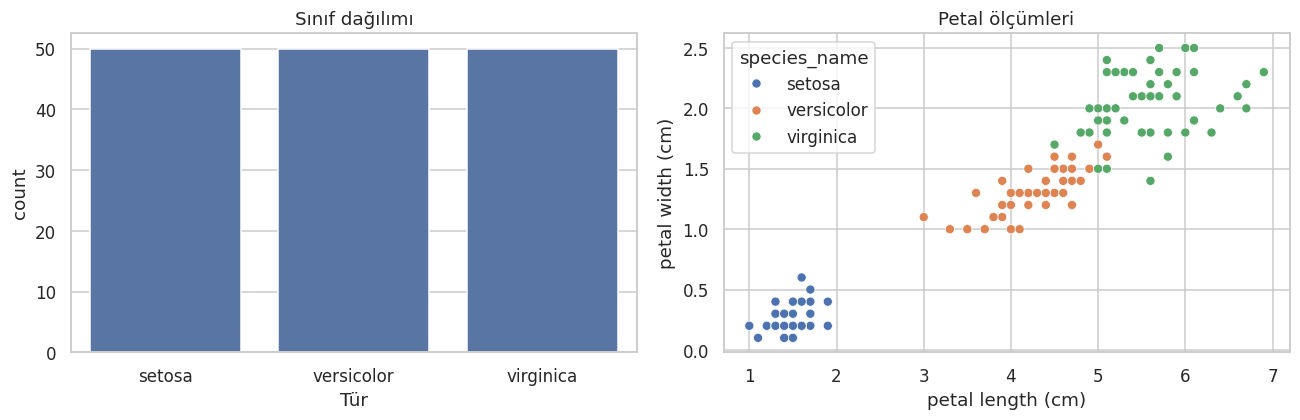

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="species_name", ax=axes[0])
axes[0].set(title="Sınıf dağılımı", xlabel="Tür")
sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)",
                hue="species_name", ax=axes[1])
axes[1].set(title="Petal ölçümleri")
plt.tight_layout(); plt.show()

## 2. Modelleme ve sınıf bazlı değerlendirme

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



,accuracy
Lojistik Regresyon,0.921
Random Forest,0.895


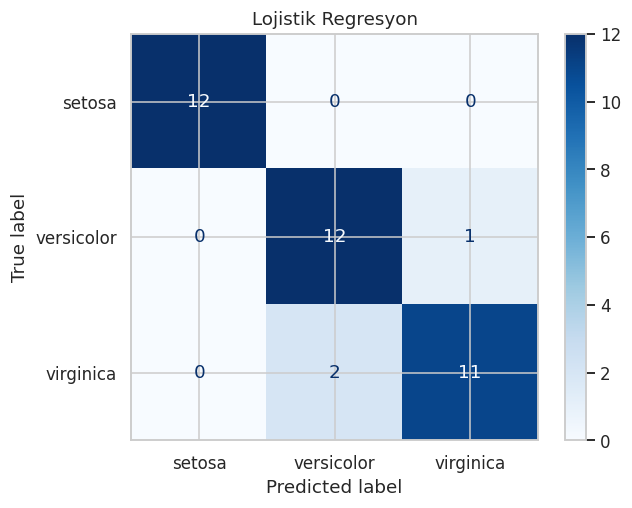

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X, y = d.data, d.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.25, stratify=y, random_state=RANDOM_STATE
)
candidates = {
    "Lojistik Regresyon": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}
fitted = {name: model.fit(X_train, y_train) for name, model in candidates.items()}
scores = pd.Series({name: accuracy_score(y_test, model.predict(X_test))
                    for name, model in fitted.items()}, name="accuracy").sort_values(ascending=False)
display(scores.to_frame().round(3))
best_name = scores.index[0]; best_model = fitted[best_name]
pred = best_model.predict(X_test)
print(classification_report(y_test, pred, target_names=d.target_names))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=d.target_names, cmap="Blues")
plt.title(best_name); plt.show()

In [5]:
joblib.dump({"best_name": best_name, "best_model": best_model,
             "all_models": fitted, "feature_names": d.feature_names,
             "target_names": d.target_names.tolist(), "accuracy": scores.to_dict()},
            MODEL_DIR / "04_iris.joblib")
json.dump({"best_model": best_name, "accuracy": float(scores.iloc[0])},
          open(RESULT_DIR / "04_iris.json", "w"), indent=2)

## Sonuç

Veri dengeli olduğu için accuracy anlamlıdır; yine de precision, recall ve F1 değerleri sınıf bazında
ayrıca raporlandı. Petal uzunluğu ve genişliği türleri sepal ölçümlerine göre daha görünür biçimde
ayırmaktadır.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **Iris üzerinde temel sınıflandırma** biçimindedir.
Bu notebookta **sınıf dengesi, iki model, sınıf bazlı metrikler ve confusion matrix** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).